# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
import pandas as pd

df = pd.read_csv('train.csv')

display(df.head())

df.info()

print("\n Кількість пропущених значень")
print(df.isna().sum())

df_cleaned = df.dropna().reset_index(drop=True)

print("\n Кількість пропущених значень після очищення")
print(df_cleaned.isna().sum())

print(f"\nРозмірність: {df_cleaned.shape}")

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB

 Кількість пропущених значень
textID           0
text             1
selected_text    1
sentiment        0
dtype: int64

 Кількість пропущених значень після очищення
textID           0
text             0
selected_text    0
sentiment        0
dtype: int64

Розмірність: (27480, 4)


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

 частка кожного класу
sentiment
neutral     40.45
positive    31.23
negative    28.32
Name: proportion, dtype: float64


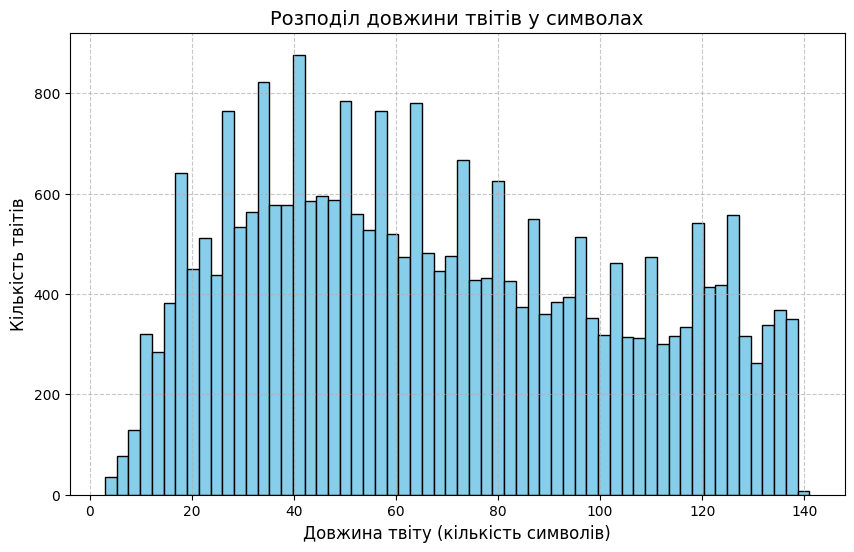


 Статистика довжини текстів
count    27480.000000
mean        68.330022
std         35.603870
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        141.000000
Name: text_len, dtype: float64


In [2]:
import matplotlib.pyplot as plt

print(df_cleaned['sentiment'].value_counts())

print("\n частка кожного класу")
print(df_cleaned['sentiment'].value_counts(normalize=True).round(4) * 100)

df_cleaned['text_len'] = df_cleaned['text'].str.len()

plt.figure(figsize=(10, 6))
df_cleaned['text_len'].hist(bins=60, color='skyblue', edgecolor='black')

plt.title('Розподіл довжини твітів у символах', fontsize=14)
plt.xlabel('Довжина твіту (кількість символів)', fontsize=12)
plt.ylabel('Кількість твітів', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\n Статистика довжини текстів")
print(df_cleaned['text_len'].describe())

Більшість постів короткі від 30 до 80 символів. Історичний ліміт у 140 символів.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [3]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import string
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

english_stopwords = stopwords.words('english')
stemmer = SnowballStemmer(language='english')

def custom_tokenizer(text):
  tokens = word_tokenize(text)

  cleaned_stemmed_tokens = []
  for word in tokens:
    word_lower = word.lower()
    if (word_lower not in english_stopwords) and (word_lower not in string.punctuation):
      stemmed_word = stemmer.stem(word_lower)
      cleaned_stemmed_tokens.append(stemmed_word)

  return cleaned_stemmed_tokens

bow_vectorizer = CountVectorizer(tokenizer=custom_tokenizer, max_features=4000, token_pattern=None)

X_bow = bow_vectorizer.fit_transform(df_cleaned['text'])

print(f"Розмірність: {X_bow.shape}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Розмірність: (27480, 4000)


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow,
    df_cleaned['sentiment'],
    test_size=0.3,
    random_state=42
)

print(f"навчальна вибірка: {X_train_bow.shape}")
print(f"тестова вибірка: {X_test_bow.shape}\n")

print("Logistic Regression")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_bow, y_train)

lr_preds = lr_model.predict(X_test_bow)
lr_accuracy = accuracy_score(y_test, lr_preds)
print(f"Accuracy: {lr_accuracy:.4f}")

print("\n MultinomialNB")
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

nb_preds = nb_model.predict(X_test_bow)
nb_accuracy = accuracy_score(y_test, nb_preds)
print(f"Accuracy: {nb_accuracy:.4f}")

best_preds = lr_preds if lr_accuracy >= nb_accuracy else nb_preds
best_model_name = "Logistic Regression" if lr_accuracy >= nb_accuracy else "MultinomialNB"

print(f"\n Метрики для {best_model_name}")
print(classification_report(y_test, best_preds))

навчальна вибірка: (19236, 4000)
тестова вибірка: (8244, 4000)

Logistic Regression
Accuracy: 0.6818

 MultinomialNB
Accuracy: 0.6468

 Метрики для Logistic Regression
              precision    recall  f1-score   support

    negative       0.69      0.59      0.64      2356
     neutral       0.63      0.72      0.67      3343
    positive       0.75      0.72      0.73      2545

    accuracy                           0.68      8244
   macro avg       0.69      0.68      0.68      8244
weighted avg       0.69      0.68      0.68      8244



Якість класифікації не ідеальна.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [5]:
feature_names = bow_vectorizer.get_feature_names_out()

classes = lr_model.classes_
print(f"Класи: {classes}\n")

for i, class_name in enumerate(classes):
  word_weights = pd.Series(lr_model.coef_[i], index=feature_names)

  print(f"Топ 10 слів у класі: {class_name}")
  print(word_weights.sort_values(ascending=False).head(10))
  print("\n")

Класи: ['negative' 'neutral' 'positive']

Топ 10 слів у класі: negative
sad           2.595822
suck          2.485342
bore          2.365832
sorri         2.319935
hate          2.197873
miss          2.100956
fail          2.049358
disappoint    2.007837
shame         1.992770
worst         1.964473
dtype: float64


Топ 10 слів у класі: neutral
starwarsday    1.301083
jst            1.300754
idol           1.155422
fals           1.145139
logic          1.120070
opinion        1.101078
cop            1.058574
^^             1.029658
cassi          1.027814
semest         1.015394
dtype: float64


Топ 10 слів у класі: positive
awesom       2.833616
thank        2.543934
cute         2.431081
love         2.261580
amaz         2.184977
enjoy        2.179658
great        2.091538
congrat      2.063179
nice         2.054574
congratul    2.050343
dtype: float64




Так, це логічно.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer, max_features=4000, token_pattern=None)

X_tfidf = tfidf_vectorizer.fit_transform(df_cleaned['text'])
print(f"X_tfidf: {X_tfidf.shape}\n")

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf,
    df_cleaned['sentiment'],
    test_size=0.3,
    random_state=42
)

lr_tfidf_model = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf_model.fit(X_train_tfidf, y_train_tfidf)

lr_tfidf_preds = lr_tfidf_model.predict(X_test_tfidf)
tfidf_accuracy = accuracy_score(y_test_tfidf, lr_tfidf_preds)

print(f"Accuracy TF-IDF: {tfidf_accuracy:.4f}")
print(f"Accuracy Bag of Words: {lr_accuracy:.4f}\n")

print(classification_report(y_test_tfidf, lr_tfidf_preds))

feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()

classes_tfidf = lr_tfidf_model.classes_
print(f"Класи: {classes_tfidf}\n")

for i, class_name in enumerate(classes_tfidf):
  word_weights_tfidf = pd.Series(lr_tfidf_model.coef_[i], index=feature_names_tfidf)
  print(f"Топ 10 слів у класі: {class_name}")
  print(word_weights_tfidf.sort_values(ascending=False).head(10))
  print("\n")

X_tfidf: (27480, 4000)

Accuracy TF-IDF: 0.6827
Accuracy Bag of Words: 0.6818

              precision    recall  f1-score   support

    negative       0.71      0.57      0.63      2356
     neutral       0.62      0.75      0.68      3343
    positive       0.77      0.70      0.73      2545

    accuracy                           0.68      8244
   macro avg       0.70      0.67      0.68      8244
weighted avg       0.69      0.68      0.68      8244

Класи: ['negative' 'neutral' 'positive']

Топ 10 слів у класі: negative
sad       5.018945
miss      4.957514
sorri     4.402905
suck      4.255084
hate      4.079265
bore      3.858143
fail      3.470281
stupid    3.333643
sick      3.282700
poor      3.196136
dtype: float64


Топ 10 слів у класі: neutral
starwarsday    1.062538
thru           1.003783
msn            0.996247
jst            0.996000
question       0.924709
cop            0.916651
logic          0.883027
how            0.879486
except         0.876928
fals           0

Так, якість класифікації покращилася. Для фінального рішення обираю TF-IDF. TF-IDF знизив вагу часто вживаних слів в корпусі текстів, натомість максимізувавши значення унікальних токенів, які виступають чіткими маркерами.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [8]:
test_indices = y_test_tfidf.index

test_analysis_df = df_cleaned.loc[test_indices].copy()

test_analysis_df['predicted_sentiment'] = lr_tfidf_preds

errors_df = test_analysis_df[test_analysis_df['sentiment'] != test_analysis_df['predicted_sentiment']]

print(f"Загальна кількість помилок на тестовій вибірці: {len(errors_df)} з {len(test_analysis_df)}")
print(f"Відсоток помилок: {(len(errors_df) / len(test_analysis_df) * 100):.2f}%\n")

print("Приклади твітів, на яких модель помилилася")
pd.set_option('display.max_colwidth', None)
display(errors_df[['text', 'sentiment', 'predicted_sentiment']].sample(15, random_state=42))

Загальна кількість помилок на тестовій вибірці: 2616 з 8244
Відсоток помилок: 31.73%

Приклади твітів, на яких модель помилилася


,text,sentiment,predicted_sentiment
27389,Safe flight home to you and Jade ****,positive,neutral
5528,Still Doing Grench paper and still getting distracted,negative,neutral
25550,I don`t wanna be single the rest of my life,positive,negative
2225,Moment of truth!! Im nervous for her!,neutral,negative
4463,Female and Male 3 year old Labs looking for new home Family is loosing their home. Both must stay together. Contact me if interested.,neutral,positive
9000,"inoo thats why i sed ino how u feel coz im in love with kyle, i feel like such a saddo but its true ha i wanna see him tuesday",negative,positive
24558,"already knows 3 dishes: Torta, Hotdog, & Itlog. Hurrah for me!",positive,neutral
21324,"nice work buying coda dude! It`s a great app! Unfortunately, I bought it when it was the full $99USD #jealous",neutral,positive
22109,Shen computer just broke Time to get the old IBM out...,neutral,negative
3740,looking forward to the show tonight. Can`t wait for ol mate to,neutral,positive


#### Аналіз помилок:
1. Проблема ігнорування заперечень та модифікаторів сенсу
2. Сарказм, іронія та прихований контекст
3. Суб'єктивність в розмітці
#### Рекомендації для покращення:
1. Перехід на N-грами
2. Використання TweetTokenizer
3. Використання нейромереж (BERT)

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model